<a href="https://colab.research.google.com/github/shriyam943/CNN/blob/main/HR_Data(LogisticRegression)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pwd

'/content'

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('hr_data.csv')

# Domain Analysis:
1)Duration to accept offer
2)Notice period
3)Joining Bonus
4)DOJ Extended
5)Gender
6)Candidate Source
7)Age
8)Status

Outcome target:
0-joined & 1-not joined.




In [ ]:
data.head()

,SLNO,Candidate Ref,DOJ Extended,Duration to accept offer,Notice period,Offered band,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Rex in Yrs,LOB,Location,Age,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,ERS,Noida,34,Joined
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,INFRA,Chennai,34,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,INFRA,Noida,27,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,INFRA,Noida,34,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,INFRA,Noida,34,Joined


In [ ]:
data

,SLNO,Candidate Ref,DOJ Extended,Duration to accept offer,Notice period,Offered band,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Rex in Yrs,LOB,Location,Age,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,ERS,Noida,34,Joined
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,INFRA,Chennai,34,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,INFRA,Noida,27,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,INFRA,Noida,34,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,INFRA,Noida,34,Joined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,12319,3822427,No,4,0,E1,191.67,191.67,0.00,No,No,Male,Employee Referral,1,ERS,Chennai,34,Joined
8991,12327,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,No,Female,Direct,3,BFSI,Chennai,34,Joined
8992,12331,3834159,No,0,0,E2,35.42,35.42,0.00,No,No,Male,Direct,5,INFRA,Noida,34,Joined
8993,12332,3835433,No,0,30,E1,76.92,53.85,-13.04,No,No,Male,Direct,4,INFRA,Noida,34,Joined


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SLNO                         8995 non-null   int64  
 1   Candidate Ref                8995 non-null   int64  
 2   DOJ Extended                 8995 non-null   object 
 3   Duration to accept offer     8995 non-null   int64  
 4   Notice period                8995 non-null   int64  
 5   Offered band                 8995 non-null   object 
 6   Pecent hike expected in CTC  8995 non-null   float64
 7   Percent hike offered in CTC  8995 non-null   float64
 8   Percent difference CTC       8995 non-null   float64
 9   Joining Bonus                8995 non-null   object 
 10  Candidate relocate actual    8995 non-null   object 
 11  Gender                       8995 non-null   object 
 12  Candidate Source             8995 non-null   object 
 13  Rex in Yrs        

In [ ]:
data.describe()

,SLNO,Candidate Ref,Duration to accept offer,Notice period,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Rex in Yrs,Age
count,8995.000000,8.995000e+03,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000,8995.000000
mean,5970.984325,2.843647e+06,21.434464,39.291829,43.864804,40.657356,-1.573802,4.239022,29.913174
std,3373.963454,4.863448e+05,25.811616,22.220239,29.788975,36.064060,19.610729,2.547571,4.097912
min,1.000000,2.109586e+06,0.000000,0.000000,-68.830000,-60.530000,-67.270000,0.000000,20.000000
25%,3207.500000,2.386476e+06,3.000000,30.000000,27.270000,22.090000,-8.330000,3.000000,27.000000
50%,5976.000000,2.807482e+06,10.000000,30.000000,40.000000,36.000000,0.000000,4.000000,29.000000
75%,8739.000000,3.300060e+06,33.000000,60.000000,53.850000,50.000000,0.000000,6.000000,34.000000
max,12333.000000,3.836076e+06,224.000000,120.000000,359.770000,471.430000,300.000000,24.000000,60.000000


In [ ]:
data.tail()

,SLNO,Candidate Ref,DOJ Extended,Duration to accept offer,Notice period,Offered band,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Rex in Yrs,LOB,Location,Age,Status
8990,12319,3822427,No,4,0,E1,191.67,191.67,0.00,No,No,Male,Employee Referral,1,ERS,Chennai,34,Joined
8991,12327,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,No,Female,Direct,3,BFSI,Chennai,34,Joined
8992,12331,3834159,No,0,0,E2,35.42,35.42,0.00,No,No,Male,Direct,5,INFRA,Noida,34,Joined
8993,12332,3835433,No,0,30,E1,76.92,53.85,-13.04,No,No,Male,Direct,4,INFRA,Noida,34,Joined
8994,12333,3836076,No,2,0,E1,45.25,14.09,-21.45,No,No,Female,Employee Referral,1,INFRA,Chennai,34,Joined


In [ ]:
data.dtypes

,0
SLNO,int64
Candidate Ref,int64
DOJ Extended,object
Duration to accept offer,int64
Notice period,int64
Offered band,object
Pecent hike expected in CTC,float64
Percent hike offered in CTC,float64
Percent difference CTC,float64
Joining Bonus,object


In [ ]:
data.columns

Index(['SLNO', 'Candidate Ref', 'DOJ Extended', 'Duration to accept offer',
       'Notice period', 'Offered band', 'Pecent hike expected in CTC',
       'Percent hike offered in CTC', 'Percent difference CTC',
       'Joining Bonus', 'Candidate relocate actual', 'Gender',
       'Candidate Source', 'Rex in Yrs', 'LOB', 'Location', 'Age', 'Status'],
      dtype='object')

In [ ]:
len(data.columns)

18

In [ ]:
data.isnull().sum()

,0
SLNO,0
Candidate Ref,0
DOJ Extended,0
Duration to accept offer,0
Notice period,0
Offered band,0
Pecent hike expected in CTC,0
Percent hike offered in CTC,0
Percent difference CTC,0
Joining Bonus,0


In [ ]:
data.drop(
    columns=[
        'SLNO',
        'Candidate Ref',
        'Offered band',
        'Pecent hike expected in CTC',
        'Percent hike offered in CTC',
        'Percent difference CTC',
        'Rex in Yrs',
        'LOB',
        'Location'
    ],
    inplace=True
)


In [ ]:
data.head()

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status
0,Yes,14,30,No,No,Female,Agency,34,Joined
1,No,18,30,No,No,Male,Employee Referral,34,Joined
2,No,3,45,No,No,Male,Agency,27,Joined
3,No,26,30,No,No,Male,Employee Referral,34,Joined
4,Yes,1,120,No,Yes,Male,Employee Referral,34,Joined


In [ ]:
data.rename(columns={"Candidate relocate actual ":"Relocation Status"},inplace=True)

In [ ]:
data

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status
0,Yes,14,30,No,No,Female,Agency,34,Joined
1,No,18,30,No,No,Male,Employee Referral,34,Joined
2,No,3,45,No,No,Male,Agency,27,Joined
3,No,26,30,No,No,Male,Employee Referral,34,Joined
4,Yes,1,120,No,Yes,Male,Employee Referral,34,Joined
...,...,...,...,...,...,...,...,...,...
8990,No,4,0,No,No,Male,Employee Referral,34,Joined
8991,Yes,2,0,No,No,Female,Direct,34,Joined
8992,No,0,0,No,No,Male,Direct,34,Joined
8993,No,0,30,No,No,Male,Direct,34,Joined


In [ ]:
len(data.columns)

9

In [ ]:
data.duplicated().sum()

np.int64(2283)

In [ ]:
data['Status'].unique()

array(['Joined', 'Not Joined'], dtype=object)

In [ ]:
data['Status'].value_counts()

,count
Status,
Joined,7313
Not Joined,1682


# EDA

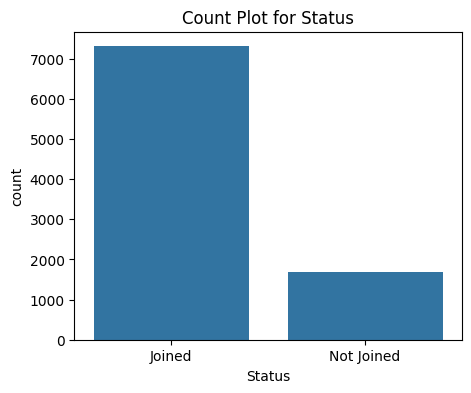

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x=data['Status'])
plt.title("Count Plot for Status")
plt.show()

In [ ]:
data.nunique()

,0
DOJ Extended,2
Duration to accept offer,136
Notice period,7
Joining Bonus,2
Candidate relocate actual,2
Gender,2
Candidate Source,3
Age,33
Status,2


In [ ]:
data['Duration to accept offer'].unique()

array([ 14,  18,   3,  26,   1,  17,  37,  16,   6, 120,  44,   7,  98,
         0,  83,  32,  19,   4,  38,  24,  10,  53,   5,  46,   2,  31,
        54,  33, 105,  69,  68,  84,  28, 126, 106,  90,  21,  36,  34,
        20,  13,   8,  42,  12, 103,  43,  60,  23,  67,  15,  45,  25,
        47,  11,  48,  74,  30,  40,  35,  58,  29,  86,  51,  50,  39,
        57,  93,  55,  71,  56,  66,  62,   9,  64, 107,  27,  78,  22,
        49,  92,  61,  79,  77, 108,  70,  82, 210,  80,  97,  41,  59,
        88,  99,  63, 111,  87,  95,  52,  96,  91, 101,  65, 140,  76,
        73, 123, 104,  72, 117, 109,  89, 127,  81,  85,  75, 118, 114,
       110, 129, 124, 116, 181,  94, 121, 119, 102, 113, 115, 125, 131,
       100, 130, 224, 143, 122, 163])

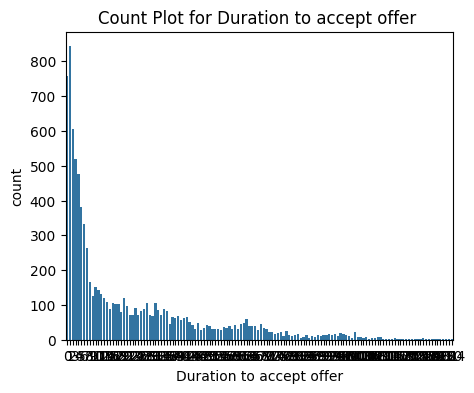

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x=data['Duration to accept offer'])
plt.title("Count Plot for Duration to accept offer ")
plt.show()

In [ ]:
data.shape[1]


9

ValueError: could not convert string to float: 'Yes'

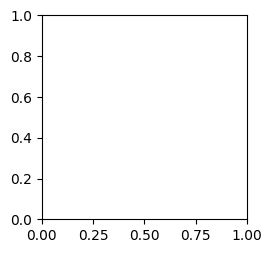

In [ ]:
plt.figure(figsize=(9,9))
plot = 1

for i in data:
  if plot<=9:
    ax = plt.subplot(3,3,plot)
    sns.distplot(x=data[i])
    plt.xlabel(i)
    plot+=1
plt.tight_layout()

<Axes: xlabel='Notice period', ylabel='count'>

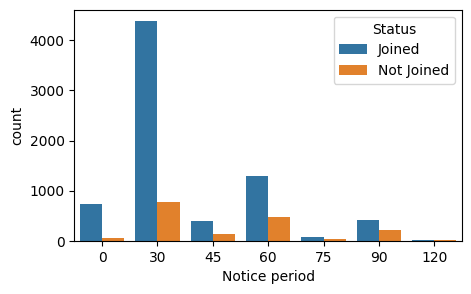

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x=data['Notice period'],hue=data['Status'])


<Axes: xlabel='Joining Bonus', ylabel='count'>

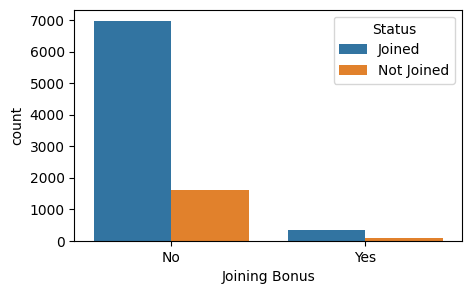

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x=data['Joining Bonus'],hue=data['Status'])


<Axes: xlabel='Gender', ylabel='count'>

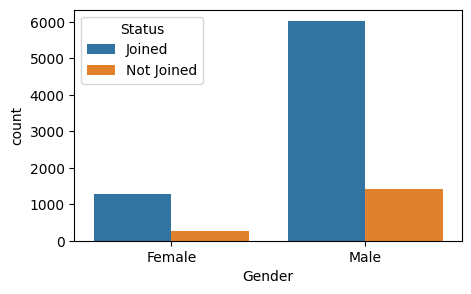

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x=data['Gender'],hue=data['Status'])


<Axes: xlabel='Candidate Source', ylabel='count'>

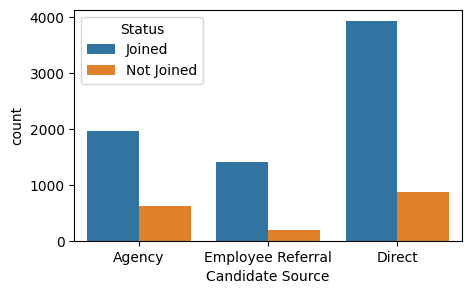

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x=data['Candidate Source'],hue=data['Status'])

<Axes: xlabel='Age', ylabel='count'>

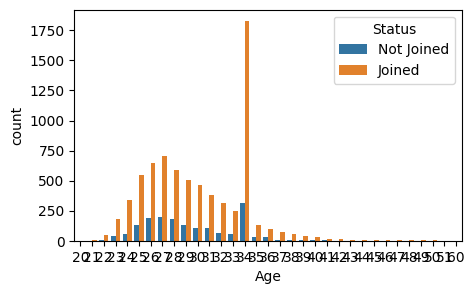

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x=data['Age'],hue=data['Status'])

In [ ]:
data.columns

Index(['DOJ Extended', 'Duration to accept offer', 'Notice period',
       'Joining Bonus', 'Candidate relocate actual', 'Gender',
       'Candidate Source', 'Age', 'Status'],
      dtype='object')

<Axes: xlabel='DOJ Extended', ylabel='Count'>

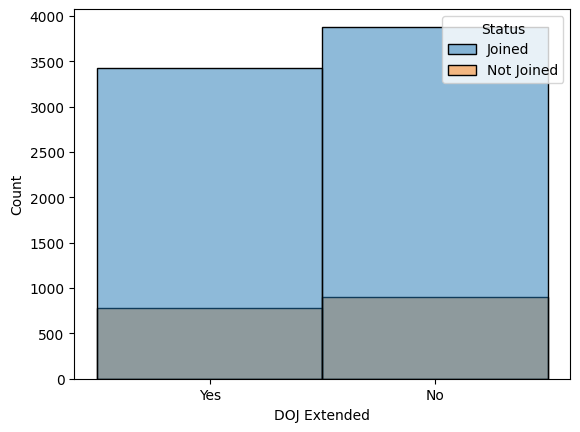

In [ ]:
sns.histplot(x=data['DOJ Extended'],hue=data['Status'])

<Axes: xlabel='Duration to accept offer', ylabel='Count'>

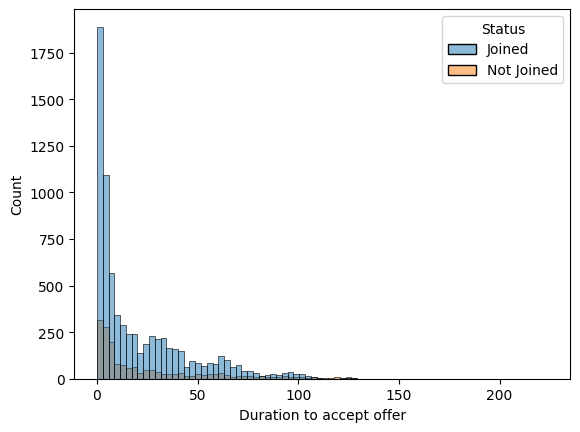

In [ ]:
sns.histplot(x=data['Duration to accept offer'],hue=data['Status'])

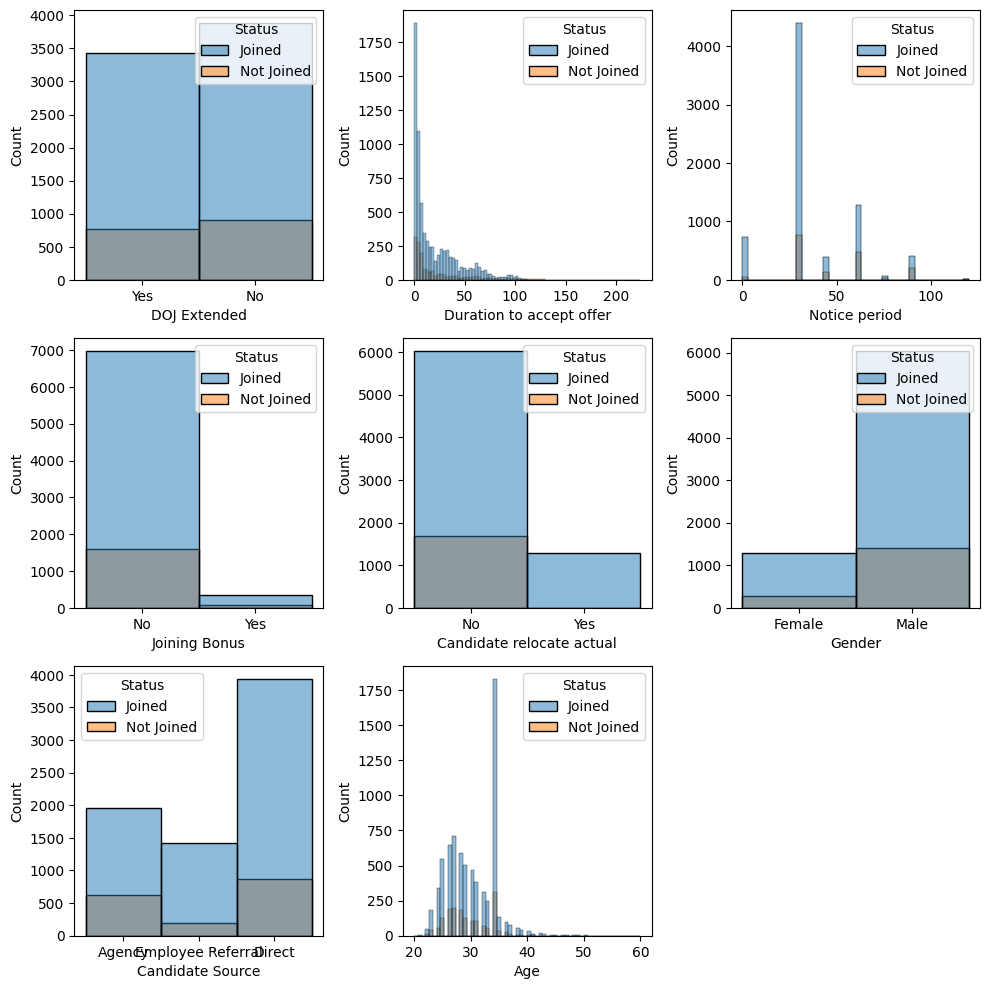

In [ ]:
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop('Status',axis=1):
  if plotnumber <= 9:
    ax = plt.subplot(3,3,plotnumber)
    sns.histplot(x=data[i],hue=data['Status'])
    plt.xlabel(i,fontsize=10)
    plotnumber+=1
plt.tight_layout()

# Pair Plot

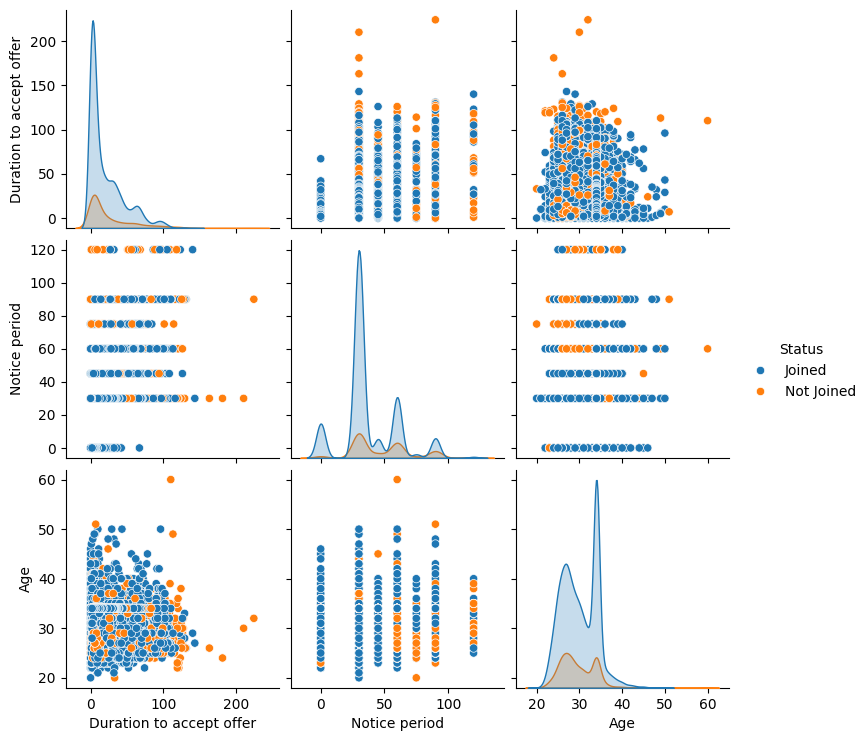

In [ ]:
sns.pairplot(data,hue='Status')

# Pre Processing

In [ ]:
data.head()

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status
0,Yes,14,30,No,No,Female,Agency,34,Joined
1,No,18,30,No,No,Male,Employee Referral,34,Joined
2,No,3,45,No,No,Male,Agency,27,Joined
3,No,26,30,No,No,Male,Employee Referral,34,Joined
4,Yes,1,120,No,Yes,Male,Employee Referral,34,Joined


In [ ]:
data.isnull().sum()

,0
DOJ Extended,0
Duration to accept offer,0
Notice period,0
Joining Bonus,0
Candidate relocate actual,0
Gender,0
Candidate Source,0
Age,0
Status,0


In [ ]:
data.duplicated().sum()

np.int64(2283)

In [ ]:
data.columns

Index(['DOJ Extended', 'Duration to accept offer', 'Notice period',
       'Joining Bonus', 'Candidate relocate actual', 'Gender',
       'Candidate Source', 'Age', 'Status'],
      dtype='object')

In [ ]:
data.loc[data['DOJ Extended']==0]

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status


In [ ]:
data['DOJ Extended'].median()

TypeError: Cannot convert ['Yes' 'No' 'No' ... 'No' 'No' 'No'] to numeric

In [ ]:
data.describe()

,Duration to accept offer,Notice period,Age,Status,Status_encoded
count,8995.000000,8995.000000,8995.000000,0.0,0.0
mean,21.434464,39.291829,29.913174,NaN,NaN
std,25.811616,22.220239,4.097912,NaN,NaN
min,0.000000,0.000000,20.000000,NaN,NaN
25%,3.000000,30.000000,27.000000,NaN,NaN
50%,10.000000,30.000000,29.000000,NaN,NaN
75%,33.000000,60.000000,34.000000,NaN,NaN
max,224.000000,120.000000,60.000000,NaN,NaN


ValueError: List of boxplot statistics and `positions` values must have same the length

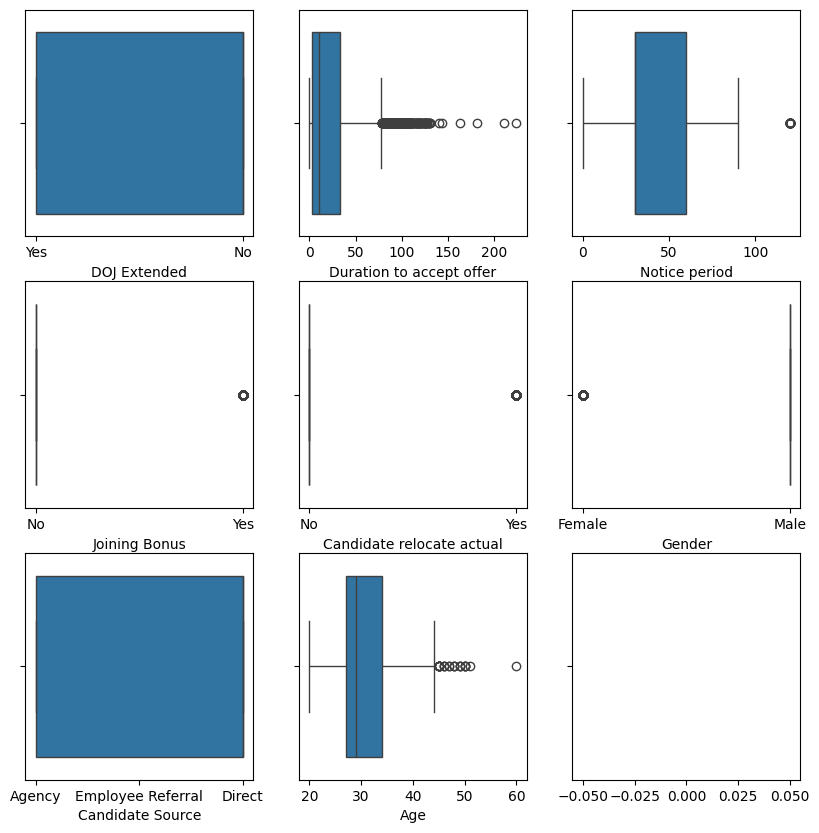

In [ ]:
plt.figure(figsize=(10,10))
plotnumber = 1

for i in data.drop('Status',axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.boxplot(x=data[i])
        plt.xlabel(i,fontsize=10)
    plotnumber +=1
plt.tight_layout()

ValueError: could not convert string to float: 'No'

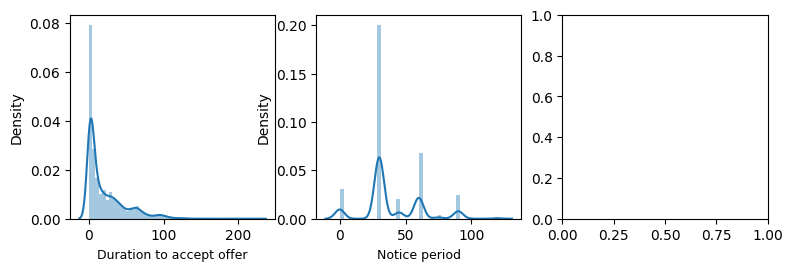

In [ ]:
plt.figure(figsize=(9,9))
plotnumber = 1

for i in data.drop(columns=['DOJ Extended','Status'],axis=1):
    if plotnumber <= 9:
        ax = plt.subplot(3,3,plotnumber)
        sns.distplot(x=data[i])
        plt.xlabel(i,fontsize=9)
    plotnumber +=1
plt.tight_layout()

In [ ]:
data.columns

Index(['DOJ Extended', 'Duration to accept offer', 'Notice period',
       'Joining Bonus', 'Candidate relocate actual', 'Gender',
       'Candidate Source', 'Age', 'Status', 'Status_encoded'],
      dtype='object')

In [ ]:
q1=data['Duration to accept offer'].quantile(0.25)
q1

np.float64(3.0)

In [ ]:
q3=data['Duration to accept offer'].quantile(0.75)
q3

np.float64(33.0)

In [ ]:
iqr=q3-q1
iqr

np.float64(30.0)

In [ ]:
lower = q1-1.5*iqr
lower

np.float64(-42.0)

In [ ]:
upper = q3+1.5*iqr
upper

np.float64(78.0)

In [ ]:
data.loc[data['Duration to accept offer']<lower]

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status,Status_encoded


In [ ]:
data.loc[data['Duration to accept offer']<upper]

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status,Status_encoded
0,Yes,14,30,No,No,Female,Agency,34,NaN,NaN
1,No,18,30,No,No,Male,Employee Referral,34,NaN,NaN
2,No,3,45,No,No,Male,Agency,27,NaN,NaN
3,No,26,30,No,No,Male,Employee Referral,34,NaN,NaN
4,Yes,1,120,No,Yes,Male,Employee Referral,34,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,No,No,Male,Employee Referral,34,NaN,NaN
8991,Yes,2,0,No,No,Female,Direct,34,NaN,NaN
8992,No,0,0,No,No,Male,Direct,34,NaN,NaN
8993,No,0,30,No,No,Male,Direct,34,NaN,NaN


In [ ]:
len(data.loc[data['Duration to accept offer']>upper])

394

In [ ]:
len(data)

8995

In [ ]:
(len(data.loc[data['Duration to accept offer']>upper])/len(data))*100

4.380211228460255

In [ ]:
data['Duration to accept offer'].median()

10.0

In [ ]:
data.loc[data['Duration to accept offer']>upper,'Duration to accept offer']=data['Duration to accept offer'].median()

<Axes: xlabel='Duration to accept offer'>

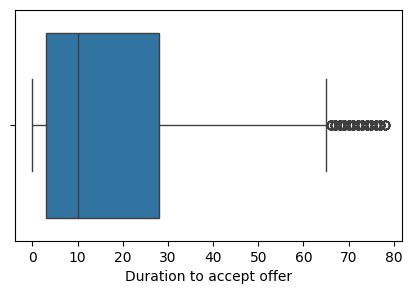

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['Duration to accept offer'])

<Axes: xlabel='Notice period'>

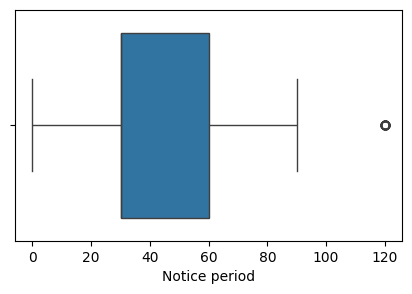

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['Notice period'])

In [ ]:
q1=data['Notice period'].quantile(0.25)
q1

np.float64(30.0)

In [ ]:
q3=data['Notice period'].quantile(0.75)
q3

np.float64(60.0)

In [ ]:
iqr=q3-q1
iqr

np.float64(30.0)

In [ ]:
lower=q1-1.5*iqr
lower

np.float64(-15.0)

In [ ]:
upper=q3+1.5*iqr
upper


np.float64(105.0)

In [ ]:
data.loc[data['Notice period']<lower]

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status,Status_encoded


In [ ]:
data.loc[data['Notice period']<upper]

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status,Status_encoded
0,Yes,14,30,No,No,Female,Agency,34,NaN,NaN
1,No,18,30,No,No,Male,Employee Referral,34,NaN,NaN
2,No,3,45,No,No,Male,Agency,27,NaN,NaN
3,No,26,30,No,No,Male,Employee Referral,34,NaN,NaN
5,Yes,17,30,No,No,Male,Employee Referral,34,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,No,No,Male,Employee Referral,34,NaN,NaN
8991,Yes,2,0,No,No,Female,Direct,34,NaN,NaN
8992,No,0,0,No,No,Male,Direct,34,NaN,NaN
8993,No,0,30,No,No,Male,Direct,34,NaN,NaN


In [ ]:
len(data.loc[data['Notice period']>upper])

42

In [ ]:
len(data)

8995

In [ ]:
(len(data.loc[data['Notice period']>upper])/len(data))*100

0.4669260700389105

In [ ]:
data['Notice period'].median()

30.0

<Axes: xlabel='Notice period'>

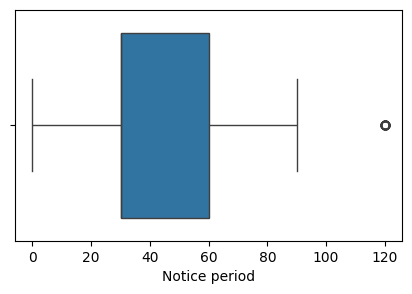

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['Notice period'])

<Axes: xlabel='Joining Bonus'>

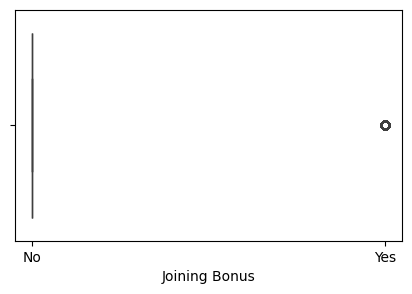

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['Joining Bonus'])

<Axes: xlabel='Age'>

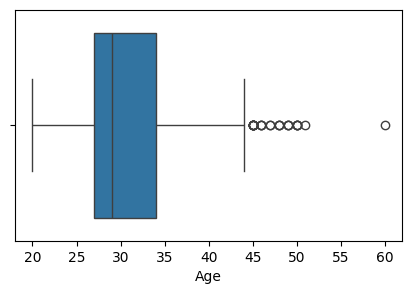

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['Age'])

In [ ]:
q1=data['Age'].quantile(0.25)
q1

np.float64(27.0)

In [ ]:
q3=data['Age'].quantile(0.75)
q3

np.float64(34.0)

In [ ]:
iqr=q3-q1
iqr

np.float64(33.0)

In [ ]:
lower=q1-1.5*iqr
lower

np.float64(-22.5)

In [ ]:
upper=q3+1.5*iqr
upper

np.float64(109.5)

In [ ]:
data.loc[data['Age']<lower]

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status,Status_encoded


In [ ]:
data.loc[data['Age']<upper]

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status,Status_encoded
0,Yes,14,30,No,No,Female,Agency,34,NaN,NaN
1,No,18,30,No,No,Male,Employee Referral,34,NaN,NaN
2,No,3,45,No,No,Male,Agency,27,NaN,NaN
3,No,26,30,No,No,Male,Employee Referral,34,NaN,NaN
4,Yes,1,120,No,Yes,Male,Employee Referral,34,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
8990,No,4,0,No,No,Male,Employee Referral,34,NaN,NaN
8991,Yes,2,0,No,No,Female,Direct,34,NaN,NaN
8992,No,0,0,No,No,Male,Direct,34,NaN,NaN
8993,No,0,30,No,No,Male,Direct,34,NaN,NaN


In [ ]:
len(data.loc[data['Age']>upper])

0

In [ ]:
len(data)

8995

In [ ]:
(len(data.loc[data['Age']>upper])/len(data))*100

0.0

In [ ]:
data['Age'].median()

29.0

In [ ]:
data.loc[data['Age']>upper,'Age']=data['Age'].median()

<Axes: xlabel='Age'>

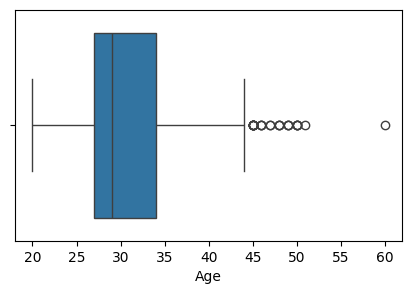

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=data['Age'])

In [ ]:
sns.heatmap(data.drop('Status',axis=1).corr(), annot=True)

ValueError: could not convert string to float: 'Yes'

In [ ]:
data.head()

,DOJ Extended,Duration to accept offer,Notice period,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Age,Status,Status_encoded
0,Yes,14,30,No,No,Female,Agency,34,NaN,NaN
1,No,18,30,No,No,Male,Employee Referral,34,NaN,NaN
2,No,3,45,No,No,Male,Agency,27,NaN,NaN
3,No,26,30,No,No,Male,Employee Referral,34,NaN,NaN
4,Yes,1,120,No,Yes,Male,Employee Referral,34,NaN,NaN


In [ ]:
y=data[['Status']]
y

,Status
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
8990,NaN
8991,NaN
8992,NaN
8993,NaN


In [ ]:
import pandas as pd
data['Status_encoded'] = data['Status'].map({'joined':1,'not joined':0})
print(data)

     DOJ Extended  Duration to accept offer  Notice period Joining Bonus  \
0             Yes                        14             30            No   
1              No                        18             30            No   
2              No                         3             45            No   
3              No                        26             30            No   
4             Yes                         1            120            No   
...           ...                       ...            ...           ...   
8990           No                         4              0            No   
8991          Yes                         2              0            No   
8992           No                         0              0            No   
8993           No                         0             30            No   
8994           No                         2              0            No   

     Candidate relocate actual  Gender   Candidate Source  Age  Status  \
0            

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train , y_test = train_test_split(x,y,test_size=0.30,random_state=2)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
encoded_x_train = x_train.apply(le.fit_transform)
print(encoded_x_train)

      DOJ Extended  Duration to accept offer  Notice period  Joining Bonus  \
7384             0                        41              5              0   
4182             1                         4              3              0   
8189             0                         1              0              0   
2972             0                         1              1              0   
839              1                        14              1              0   
...            ...                       ...            ...            ...   
1099             0                         1              1              0   
2514             1                        16              1              0   
6637             0                        56              3              0   
2575             1                        35              1              0   
7336             1                         3              1              0   

      Candidate relocate actual  Gender  Candidate Source  Age 

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train),columns=x_train.columns)
x_test = pd.DataFrame(sc.transform(x_test),columns=x_test.columns)

ValueError: could not convert string to float: 'No'

In [ ]:
from sklearn.linear_model import LogisticRegression

# init
model = LogisticRegression()

# train the model
model.fit(x_train, y_train)

ValueError: could not convert string to float: 'No'

In [ ]:
y_test

In [ ]:
y_pred = model.predict(x_test)
y_pred

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score,classification_report

In [ ]:
confusion_matrix(y_test,y_pred)

NameError: name 'y_pred' is not defined

In [ ]:
accuracy_score(y_test,y_pred)

NameError: name 'y_pred' is not defined

In [ ]:
precision_score(y_test,y_pred)

NameError: name 'y_pred' is not defined

In [ ]:
f1_score(y_test,y_pred)

NameError: name 'y_pred' is not defined

In [ ]:
recall_score(y_test,y_pred)

NameError: name 'y_pred' is not defined

In [ ]:
print(classification_report(y_test,y_pred))

NameError: name 'y_pred' is not defined

In [ ]:
from sklearn.metrics import roc_curve,auc
false_positive_rate,true_positive_rate,thresholds = roc_curve(y_test,y_pred)
auc_score=auc(false_positive_rate,true_positive_rate)
auc_score

NameError: name 'y_pred' is not defined

In [ ]:
false_positive_rate,true_positive_rate,thresholds = roc_curve(y_test,y_pred)
false_positive_rate


NameError: name 'y_pred' is not defined

In [ ]:
true_positive_rate

NameError: name 'true_positive_rate' is not defined

In [ ]:
thresholds

NameError: name 'thresholds' is not defined